# Sistema de Recomendação — BigDataECommerce

Notebook completo com 6 módulos:
1. Carregamento dos dados Gold
2. Content-Based Filtering (TF-IDF + Cosine Similarity)
3. Collaborative Filtering (ALS — dados implícitos)
4. Cold Start (clientes novos)
5. Modelo Híbrido ranqueador (XGBoost)
6. Avaliação (Precision@K)

**Como rodar:** Execute as células em ordem, de cima para baixo (`Shift+Enter` em cada uma ou `Run All`).

---
## 0. Instalação das dependências
Execute esta célula uma única vez. Se já tiver instalado, pode pular.

In [1]:
# Execute uma vez só
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install",
                       "scikit-learn", "xgboost", "implicit", "scipy", "numpy", "-q"])
print("Dependências instaladas com sucesso.")

Dependências instaladas com sucesso.


---
## 1. Carregamento dos dados Gold

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

GOLD = "../data/gold/"

interactions   = pd.read_csv(GOLD + "gold_user_product_interactions.csv")
product_feat   = pd.read_csv(GOLD + "gold_product_features.csv")
customer_prof  = pd.read_csv(GOLD + "gold_customer_profile.csv")
top_products   = pd.read_csv(GOLD + "gold_top_products_by_segment.csv")
cooccurrence   = pd.read_csv(GOLD + "gold_product_cooccurrence.csv")
cat_affinity   = pd.read_csv(GOLD + "gold_category_affinity.csv")

print("gold_user_product_interactions:", interactions.shape)
print("gold_product_features:         ", product_feat.shape)
print("gold_customer_profile:         ", customer_prof.shape)
print("gold_top_products_by_segment:  ", top_products.shape)
print("gold_product_cooccurrence:     ", cooccurrence.shape)
print("gold_category_affinity:        ", cat_affinity.shape)

gold_user_product_interactions: (101883, 8)
gold_product_features:          (32946, 12)
gold_customer_profile:          (96096, 13)
gold_top_products_by_segment:   (962, 9)
gold_product_cooccurrence:      (4053, 6)
gold_category_affinity:         (96341, 6)


In [2]:
interactions.head(3)

,customer_unique_id,product_id,product_category_name_english,purchase_count,total_spent,review_score,sentiment,implicit_score
0,c8460e4251689ba205045f3ea17884a1,e7cc48a9daff5436f63d3aad9426f28b,telephony,24,4655.88,4.0,positivo,24.4
1,698e1cf81d01a3d389d96145f7fa6df8,9571759451b1d780ee7c15012ea109d4,auto,20,2262.80,NaN,NaN,20.3
2,c402f431464c72e27330a67f7b94d4fb,ee3d532c8a438679776d222e997606b3,computers_accessories,20,2202.40,1.0,muito negativo,20.1


---
## 2. Content-Based Filtering — TF-IDF + Cosine Similarity

**O que faz:** dado um `product_id`, retorna os N produtos mais parecidos com base em características do produto (categoria, faixa de preço, nota, sentimento).  
**Não depende de histórico do cliente** — funciona para qualquer produto.

### Como funciona:
1. Para cada produto, montamos uma string com suas características (ex: `"bed_bath_table price_low score_high"`).
2. O **TF-IDF** transforma essas strings em vetores numéricos — palavras que aparecem em poucos produtos ganham mais peso.
3. A **cosine similarity** mede o ângulo entre os vetores: resultado 1.0 = idênticos, 0.0 = sem nada em comum.

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def faixa_preco(p):
    if p < 50:    return "price_very_low"
    elif p < 150: return "price_low"
    elif p < 500: return "price_medium"
    else:         return "price_high"

def faixa_nota(n):
    if pd.isna(n):  return "score_unknown"
    elif n >= 4.0:  return "score_high"
    elif n >= 3.0:  return "score_medium"
    else:           return "score_low"

def faixa_sentimento(r):
    if pd.isna(r) or r == 0: return "sentiment_unknown"
    elif r >= 0.6:            return "sentiment_positive"
    elif r >= 0.3:            return "sentiment_neutral"
    else:                     return "sentiment_negative"

pf = product_feat.copy()
pf['texto_produto'] = (
    pf['product_category_name_english'].fillna('unknown') + ' ' +
    pf['avg_price'].apply(faixa_preco) + ' ' +
    pf['avg_review_score'].apply(faixa_nota) + ' ' +
    pf['positive_sentiment_ratio'].apply(faixa_sentimento) + ' ' +
    pf['seller_state'].fillna('unknown')
)

pf = pf.set_index('product_id')

tfidf = TfidfVectorizer()
matriz_tfidf = tfidf.fit_transform(pf['texto_produto'])

print(f"Matriz TF-IDF: {matriz_tfidf.shape}")
print("Exemplo de texto gerado para o 1º produto:")
print(pf['texto_produto'].iloc[0])

Matriz TF-IDF: (32946, 107)
Exemplo de texto gerado para o 1º produto:
perfumery price_very_low score_high sentiment_unknown SP


In [4]:
produto_idx = {pid: i for i, pid in enumerate(pf.index)}

def recomendar_content_based(product_id, n=10):
    """
    Retorna os N produtos mais similares ao produto informado.
    Usa TF-IDF das características do produto + cosine similarity.
    """
    if product_id not in produto_idx:
        return pd.DataFrame(columns=['product_id', 'categoria', 'preco_medio', 'nota_media', 'similaridade'])

    idx = produto_idx[product_id]
    vetor = matriz_tfidf[idx]
    scores = cosine_similarity(vetor, matriz_tfidf).flatten()
    scores[idx] = 0

    top_idx = scores.argsort()[::-1][:n]
    result = pf.iloc[top_idx][['product_category_name_english', 'avg_price', 'avg_review_score']].copy()
    result.columns = ['categoria', 'preco_medio', 'nota_media']
    result['similaridade'] = scores[top_idx].round(4)
    result.index.name = 'product_id'
    return result.reset_index()

produto_teste = interactions['product_id'].value_counts().index[0]
cat_original  = pf.loc[produto_teste, 'product_category_name_english'] if produto_teste in pf.index else 'N/A'

print(f"Produto de referência: {produto_teste}")
print(f"Categoria: {cat_original}")
print()
recomendar_content_based(produto_teste, n=10)

Produto de referência: 99a4788cb24856965c36a24e339b6058
Categoria: bed_bath_table



,product_id,categoria,preco_medio,nota_media,similaridade
0,e5ea77a1575b40961598bca64f081976,bed_bath_table,108.7889,3.0000,1.0
1,92d9e76c3678dc402b5d1a49f1ccc7f2,bed_bath_table,117.9900,3.7500,1.0
2,5bfc7506459ae2a7b4b573fe557a58e1,bed_bath_table,69.8548,3.9032,1.0
3,4328139cbe9adde0aac493ca9871eab3,bed_bath_table,70.2000,3.6000,1.0
4,a04f52ded97b5530e8783e3c002b90f0,bed_bath_table,79.9000,3.4615,1.0
5,525947dbe3304ac32bf51602f9557c12,bed_bath_table,111.1500,3.2500,1.0
6,d59349a33fcba18707a61aa852c02c5b,bed_bath_table,69.2000,3.5000,1.0
7,0fa81e7123fd0ebe03adbbe99d912827,bed_bath_table,103.0818,3.9545,1.0
8,a2a1d57880bb40e60b59530ba0177ccf,bed_bath_table,53.3233,3.3333,1.0
9,1eaf224c19e07b6e50bf0119eea1dd26,bed_bath_table,105.3545,3.1818,1.0


---
## 3. Collaborative Filtering — ALS (Alternating Least Squares)

**O que faz:** dado um `customer_id`, retorna produtos que clientes com perfil parecido compraram — sem olhar para o conteúdo dos produtos.  

### Como funciona:
1. Montamos uma **matriz esparsa** cliente × produto onde o valor é o `implicit_score` (já calculado na camada gold).
2. O **ALS** fatoriza essa matriz em dois grupos de vetores latentes: um para clientes, outro para produtos.
3. Para recomendar: calculamos o produto interno (dot product) entre o vetor do cliente e os vetores de todos os produtos — os maiores valores são os mais recomendados.

> **Por que ALS e não SVD?** ALS é feito para dados implícitos (contagem de compras, sem nota explícita). O SVD clássico assume notas explícitas e não lida bem com zeros que significam "não comprou" vs "avaliou mal".

In [5]:
import implicit
from scipy.sparse import csr_matrix

clientes_unicos  = interactions['customer_unique_id'].unique()
produtos_unicos  = interactions['product_id'].unique()

cliente_idx = {c: i for i, c in enumerate(clientes_unicos)}
produto_idx_cf = {p: i for i, p in enumerate(produtos_unicos)}
idx_produto_cf = {i: p for p, i in produto_idx_cf.items()}
idx_cliente    = {i: c for c, i in cliente_idx.items()} 

rows = interactions['customer_unique_id'].map(cliente_idx)
cols = interactions['product_id'].map(produto_idx_cf)
vals = interactions['implicit_score'].values

matriz_usuario_produto = csr_matrix(
    (vals, (rows, cols)),
    shape=(len(clientes_unicos), len(produtos_unicos))
)

matriz_produto_usuario = matriz_usuario_produto.T.tocsr()

print(f"Clientes únicos : {len(clientes_unicos):,}")
print(f"Produtos únicos : {len(produtos_unicos):,}")
print(f"Interações      : {len(interactions):,}")
print(f"Densidade       : {len(interactions) / (len(clientes_unicos)*len(produtos_unicos))*100:.4f}%")
print(f"Matriz esparsa  : {matriz_usuario_produto.shape}")

Clientes únicos : 95,320
Produtos únicos : 32,872
Interações      : 101,883
Densidade       : 0.0033%
Matriz esparsa  : (95320, 32872)


In [6]:
modelo_als = implicit.als.AlternatingLeastSquares(
    factors=50,
    iterations=20,
    regularization=0.1,
    random_state=42
)

modelo_als.fit(matriz_usuario_produto)
print("Modelo ALS treinado com sucesso.")

  0%|          | 0/20 [00:00<?, ?it/s]

Modelo ALS treinado com sucesso.


In [7]:
def recomendar_cf(customer_unique_id, n=10):
    """
    Retorna os N produtos recomendados para o cliente via Collaborative Filtering (ALS).
    Só funciona para clientes que já têm histórico de compras.
    """
    if customer_unique_id not in cliente_idx:
        return pd.DataFrame(columns=['product_id', 'categoria', 'score_previsto'])

    uid = cliente_idx[customer_unique_id]
    ids_recomendados, scores_recomendados = modelo_als.recommend(
        uid,
        matriz_usuario_produto[uid],
        N=n,
        filter_already_liked_items=True 
    )

    product_ids = [idx_produto_cf[i] for i in ids_recomendados]

    resultado = pd.DataFrame({
        'product_id': product_ids,
        'score_previsto': scores_recomendados.round(4)
    })

    resultado = resultado.merge(
        product_feat[['product_id', 'product_category_name_english', 'avg_price', 'avg_review_score']],
        on='product_id', how='left'
    ).rename(columns={'product_category_name_english': 'categoria',
                      'avg_price': 'preco_medio', 'avg_review_score': 'nota_media'})

    return resultado

cliente_teste = interactions.groupby('customer_unique_id')['purchase_count'].sum().idxmax()
historico_cliente = interactions[interactions['customer_unique_id'] == cliente_teste]

print(f"Cliente: {cliente_teste}")
print(f"Produtos já comprados: {len(historico_cliente)}")
print(f"Categorias compradas : {historico_cliente['product_category_name_english'].unique()}")
print()
recomendar_cf(cliente_teste, n=10)

Cliente: c8460e4251689ba205045f3ea17884a1
Produtos já comprados: 1
Categorias compradas : <StringArray>
['telephony']
Length: 1, dtype: str



,product_id,score_previsto,categoria,preco_medio,nota_media
0,c6336fa91fbd87c359e44f5dca5a90ed,0.7153,sports_leisure,43.7362,4.0109
1,2028bf1b01cafb2d2b1901fca4083222,0.4899,perfumery,55.6204,4.2837
2,89321f94e35fc6d7903d36f74e351d40,0.4532,food,28.3673,3.9829
3,b532349fe46b38fbc7bb3914c1bdae07,0.4044,furniture_decor,36.4622,3.5602
4,595fac2a385ac33a80bd5114aec74eb8,0.3245,perfumery,119.2160,4.4057
5,75d6b6963340c6063f7f4cfcccfe6a30,0.3171,perfumery,56.8610,4.0968
6,c9c6fde711572c1ad99ca12728c6af00,0.2839,telephony,30.7495,4.1688
7,78efe838c04bbc568be034082200ac20,0.2610,furniture_decor,95.5069,4.3762
8,fb55982be901439613a95940feefd9ee,0.2566,stationery,80.7857,4.1605
9,777d2e438a1b645f3aec9bd57e92672c,0.2562,bed_bath_table,69.8702,4.0526


---
## 4. Cold Start — Clientes novos (sem histórico)

**O que faz:** quando um cliente não tem histórico, usa o estado ou categoria preferida dele para recomendar os produtos mais populares e bem avaliados daquele segmento.  
**Não precisa de treino nenhum** — os dados do `gold_top_products_by_segment` já estão prontos.

In [8]:
def recomendar_cold_start(estado=None, categoria=None, n=10):
    """
    Recomendação para clientes novos.
    - estado: sigla do estado (ex: 'SP', 'RJ', 'MG')
    - categoria: categoria em inglês (ex: 'sports_leisure', 'health_beauty')
    - Se nenhum for informado, retorna o ranking global.
    Prioridade: estado > categoria > global
    """
    if estado:
        resultado = top_products[
            (top_products['segment_type'] == 'state') &
            (top_products['segment_value'].str.upper() == estado.upper())
        ]
        if len(resultado) > 0:
            return resultado.sort_values('rank').head(n)[
                ['rank', 'product_id', 'product_category_name_english',
                 'avg_review_score', 'avg_price', 'total_orders']
            ].reset_index(drop=True)

    if categoria:
        resultado = top_products[
            (top_products['segment_type'] == 'category') &
            (top_products['segment_value'].str.lower() == categoria.lower())
        ]
        if len(resultado) > 0:
            return resultado.sort_values('rank').head(n)[
                ['rank', 'product_id', 'product_category_name_english',
                 'avg_review_score', 'avg_price', 'total_orders']
            ].reset_index(drop=True)

    return top_products[
        top_products['segment_type'] == 'global'
    ].sort_values('rank').head(n)[
        ['rank', 'product_id', 'product_category_name_english',
         'avg_review_score', 'avg_price', 'total_orders']
    ].reset_index(drop=True)

print("=== Cold Start: Estado SP ===")
display(recomendar_cold_start(estado='SP', n=5))

print("\n=== Cold Start: Categoria health_beauty ===")
display(recomendar_cold_start(categoria='health_beauty', n=5))

print("\n=== Cold Start: Fallback global ===")
display(recomendar_cold_start(n=5))

=== Cold Start: Estado SP ===


,rank,product_id,product_category_name_english,avg_review_score,avg_price,total_orders
0,1,aca2eb7d00ea1a7b8ebd4e68314663af,furniture_decor,4.0191,71.3641,527.0
1,2,99a4788cb24856965c36a24e339b6058,bed_bath_table,3.9021,88.1671,488.0
2,3,422879e10f46682990de24d770e7f83d,garden_tools,3.9463,54.9116,484.0
3,4,368c6c730842d78016ad823897a372db,garden_tools,3.9227,54.2701,388.0
4,5,389d119b48cf3043d311335e499d9c6b,garden_tools,4.1131,54.6954,392.0



=== Cold Start: Categoria health_beauty ===


,rank,product_id,product_category_name_english,avg_review_score,avg_price,total_orders
0,1,154e7e31ebfa092203795c972e5804a6,health_beauty,4.3297,22.5096,281.0
1,2,2b4609f8948be18874494203496bc318,health_beauty,4.0859,87.3739,260.0
2,3,7c1bd920dbdf22470b68bde975dd3ccf,health_beauty,3.8616,60.0290,231.0
3,4,bb50f2e236e5eea0100680137654686c,health_beauty,4.2205,327.6154,195.0
4,5,6cdd53843498f92890544667809f1595,health_beauty,4.3072,350.8346,156.0



=== Cold Start: Fallback global ===


,rank,product_id,product_category_name_english,avg_review_score,avg_price,total_orders
0,1,aca2eb7d00ea1a7b8ebd4e68314663af,furniture_decor,4.0191,71.3641,527.0
1,2,99a4788cb24856965c36a24e339b6058,bed_bath_table,3.9021,88.1671,488.0
2,3,422879e10f46682990de24d770e7f83d,garden_tools,3.9463,54.9116,484.0
3,4,389d119b48cf3043d311335e499d9c6b,garden_tools,4.1131,54.6954,392.0
4,5,368c6c730842d78016ad823897a372db,garden_tools,3.9227,54.2701,388.0


---
## 5. "Quem comprou também comprou" — Coocorrência com Jaccard

**O que faz:** dado um produto, retorna os produtos que foram comprados juntos com ele no mesmo pedido.  
**Útil para:** mostrar sugestões na página do produto, aumentar ticket médio.

O **índice de Jaccard** já foi calculado na camada Gold: `|A ∩ B| / |A ∪ B|` — quanto maior, mais frequente a compra conjunta.

In [9]:
def recomendar_coocorrencia(product_id, n=10):
    """
    Retorna produtos frequentemente comprados junto com o produto informado.
    Baseado no índice de Jaccard pré-calculado na camada Gold.
    """
    mask = (
        (cooccurrence['product_id_a'] == product_id) |
        (cooccurrence['product_id_b'] == product_id)
    )
    resultado = cooccurrence[mask].copy()

    if len(resultado) == 0:
        return pd.DataFrame(columns=['product_id', 'categoria', 'jaccard', 'compras_juntas'])

    resultado['product_id'] = resultado.apply(
        lambda r: r['product_id_b'] if r['product_id_a'] == product_id else r['product_id_a'],
        axis=1
    )
    resultado['categoria'] = resultado.apply(
        lambda r: r['category_b'] if r['product_id_a'] == product_id else r['category_a'],
        axis=1
    )

    return resultado.sort_values('cooccurrence_score', ascending=False).head(n)[
        ['product_id', 'categoria', 'cooccurrence_score', 'cooccurrence_count']
    ].rename(columns={'cooccurrence_score': 'jaccard', 'cooccurrence_count': 'compras_juntas'}).reset_index(drop=True)

produto_cooc_teste = cooccurrence['product_id_a'].value_counts().index[0]
print(f"Produto: {produto_cooc_teste}")
recomendar_coocorrencia(produto_cooc_teste, n=10)

Produto: 2136c70bbe723d338fab53da3c03e6dc


,product_id,categoria,jaccard,compras_juntas
0,a84d0660dbffebf352aefbf1a6b18d00,watches_gifts,0.120000,3
1,5c692818d313aa12864b48ac0c2472c2,watches_gifts,0.111111,3
2,555cdc8ae3abc9870afa02367539b799,watches_gifts,0.086957,2
3,87cb507e0daa37bbf34956fd59eba832,watches_gifts,0.074074,2
4,14a0471af2a7bc596532fc8a6f29b1f8,watches_gifts,0.045455,1
5,17fe399dea1627d099a67438b3d562a7,watches_gifts,0.045455,1
6,2295c573e69974c45434ba00300189f4,watches_gifts,0.045455,1
7,40c7fdb4c192c7df52431d1b079f9026,watches_gifts,0.045455,1
8,e7890707ac0e4e190a74aa46c92e2c94,watches_gifts,0.043478,1
9,ed836edc15625c202f6ba85dbbe95c3a,watches_gifts,0.043478,1


---
## 6. Modelo Híbrido — XGBoost Ranqueador

**O que faz:** combina os scores do CF e do Content-Based com features do cliente e do produto para treinar um modelo que aprende qual combinação gera a melhor recomendação.  

### Como funciona:
1. **Positivos:** pares (cliente, produto) que existem em `gold_user_product_interactions` (cliente realmente comprou).
2. **Negativos:** para cada cliente, amostramos produtos que ele **não** comprou — o modelo aprende a distinguir.
3. **Features:** score CF + similaridade de conteúdo + perfil do cliente + features do produto.
4. **Target:** 1 = comprou, 0 = não comprou.
5. **XGBoost** treina nessa tabela e aprende a ranquear candidatos.

In [10]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
import xgboost as xgb

clientes_com_perfil = set(customer_prof['customer_unique_id'].unique())
clientes_com_historico = set(interactions['customer_unique_id'].unique())
clientes_validos = list(clientes_com_perfil & clientes_com_historico)

np.random.seed(42)
N_CLIENTES_AMOSTRA = 5000
clientes_amostra = np.random.choice(clientes_validos,
                                     size=min(N_CLIENTES_AMOSTRA, len(clientes_validos)),
                                     replace=False)

interacoes_amostra = interactions[interactions['customer_unique_id'].isin(clientes_amostra)].copy()
print(f"Interações positivas na amostra: {len(interacoes_amostra):,}")

Interações positivas na amostra: 5,356


In [11]:
todos_produtos = interactions['product_id'].unique()

negativos = []
for cliente in clientes_amostra:
    comprados = set(interacoes_amostra[
        interacoes_amostra['customer_unique_id'] == cliente
    ]['product_id'].values)
    n_neg = len(comprados)
    nao_comprados = np.setdiff1d(todos_produtos, list(comprados))
    if len(nao_comprados) >= n_neg:
        amostrados = np.random.choice(nao_comprados, size=n_neg, replace=False)
    else:
        amostrados = nao_comprados
    for pid in amostrados:
        negativos.append({'customer_unique_id': cliente, 'product_id': pid, 'label': 0})

df_neg = pd.DataFrame(negativos)

df_pos = interacoes_amostra[['customer_unique_id', 'product_id']].copy()
df_pos['label'] = 1

df_treino = pd.concat([df_pos, df_neg], ignore_index=True)
print(f"Positivos: {len(df_pos):,} | Negativos: {len(df_neg):,} | Total: {len(df_treino):,}")

Positivos: 5,356 | Negativos: 5,356 | Total: 10,712


In [12]:
le_state  = LabelEncoder()
le_cat    = LabelEncoder()
le_pay    = LabelEncoder()

cp = customer_prof[['customer_unique_id', 'customer_state', 'total_orders',
                     'total_spent', 'avg_review_score', 'preferred_category',
                     'preferred_payment_type', 'avg_installments',
                     'avg_delivery_distance']].copy()
cp['customer_state']        = le_state.fit_transform(cp['customer_state'].fillna('unknown'))
cp['preferred_category']    = le_cat.fit_transform(cp['preferred_category'].fillna('unknown'))
cp['preferred_payment_type']= le_pay.fit_transform(cp['preferred_payment_type'].fillna('unknown'))
cp = cp.fillna(0)

le_pcat   = LabelEncoder()
le_pstate = LabelEncoder()

pf2 = product_feat[['product_id', 'product_category_name_english', 'avg_price',
                     'avg_review_score', 'total_orders', 'positive_sentiment_ratio',
                     'seller_state', 'repeat_product', 'total_sellers']].copy()
pf2['product_category_name_english'] = le_pcat.fit_transform(
    pf2['product_category_name_english'].fillna('unknown'))
pf2['seller_state'] = le_pstate.fit_transform(pf2['seller_state'].fillna('unknown'))
pf2 = pf2.fillna(0)

df_treino = df_treino.merge(cp, on='customer_unique_id', how='left')
df_treino = df_treino.merge(pf2, on='product_id', how='left')
df_treino = df_treino.fillna(0)

print(f"Features no dataset: {df_treino.shape[1]}")
df_treino.head(3)

Features no dataset: 19


,customer_unique_id,product_id,label,customer_state,total_orders_x,total_spent,avg_review_score_x,preferred_category,preferred_payment_type,avg_installments,avg_delivery_distance,product_category_name_english,avg_price,avg_review_score_y,total_orders_y,positive_sentiment_ratio,seller_state,repeat_product,total_sellers
0,0f5ac8d5c31de21d2f25e24be15bbffb,89b190a046022486c635022524a974a8,1,17,2,1544.82,5.0,39,0,5.5,645.084469,39.0,65.4900,4.7500,20.0,0.2500,22.0,0.000000,1.0
1,1f98d2384ff7a372e6a2d3bb75cbcd54,928e52a9ad53a294fdcc91bcf59d1751,1,10,2,1381.41,1.0,49,0,1.0,448.231362,49.0,135.8333,3.5862,60.0,0.1167,22.0,0.071429,1.0
2,6411590d91c48640cb07e72fbb4a359e,0e1fa2aadc04afbf8fb30200aeba06a2,1,8,1,1619.73,1.0,49,1,10.0,670.092094,49.0,129.0000,1.0000,10.0,0.0000,8.0,0.000000,1.0


In [13]:
FEATURES = [
    'customer_state', 'total_orders', 'total_spent', 'avg_review_score',
    'preferred_category', 'preferred_payment_type', 'avg_installments', 'avg_delivery_distance',
    'product_category_name_english', 'avg_price', 'avg_review_score', 'total_orders',
    'positive_sentiment_ratio', 'seller_state', 'repeat_product', 'total_sellers'
]
df_treino = df_treino.rename(columns={
    'avg_review_score_x': 'cliente_avg_review_score',
    'avg_review_score_y': 'produto_avg_review_score',
    'total_orders_x': 'cliente_total_orders',
    'total_orders_y': 'produto_total_orders'
})

FEATURES = [
    'customer_state', 'cliente_total_orders', 'total_spent', 'cliente_avg_review_score',
    'preferred_category', 'preferred_payment_type', 'avg_installments', 'avg_delivery_distance',
    'product_category_name_english', 'avg_price', 'produto_avg_review_score', 'produto_total_orders',
    'positive_sentiment_ratio', 'seller_state', 'repeat_product', 'total_sellers'
]

X = df_treino[FEATURES]
y = df_treino['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

modelo_xgb = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    verbosity=0
)

modelo_xgb.fit(X_train, y_train,
               eval_set=[(X_test, y_test)],
               verbose=False)

y_pred_proba = modelo_xgb.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC no teste: {auc:.4f}")
print("(AUC > 0.7 é considerado bom para dados de e-commerce)")
print()
print(classification_report(y_test, modelo_xgb.predict(X_test)))

AUC-ROC no teste: 0.9867
(AUC > 0.7 é considerado bom para dados de e-commerce)

              precision    recall  f1-score   support

           0       0.97      0.93      0.95      1072
           1       0.93      0.98      0.95      1071

    accuracy                           0.95      2143
   macro avg       0.95      0.95      0.95      2143
weighted avg       0.95      0.95      0.95      2143



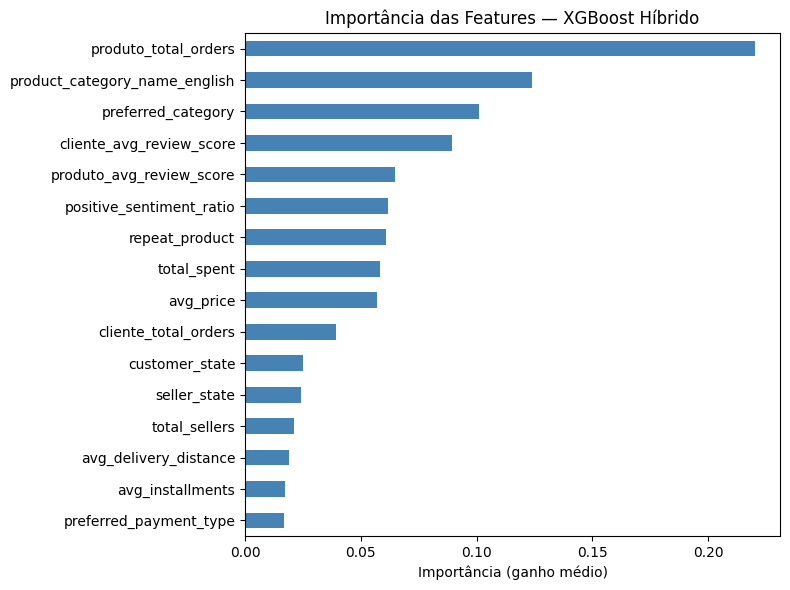

In [14]:
import matplotlib.pyplot as plt

importancias = pd.Series(modelo_xgb.feature_importances_, index=FEATURES)
importancias = importancias.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importancias.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Importância das Features — XGBoost Híbrido')
ax.set_xlabel('Importância (ganho médio)')
plt.tight_layout()
plt.show()

In [15]:
def recomendar_hibrido(customer_unique_id, n=10):
    """
    Recomendação híbrida: gera candidatos via ALS e re-ranqueia com XGBoost.
    Para clientes sem histórico, usa cold start.
    """
    if customer_unique_id not in cliente_idx:
        perfil = customer_prof[customer_prof['customer_unique_id'] == customer_unique_id]
        estado = perfil['customer_state'].values[0] if len(perfil) > 0 else None
        categoria = perfil['preferred_category'].values[0] if len(perfil) > 0 else None
        return recomendar_cold_start(estado=estado, categoria=categoria, n=n)

    uid = cliente_idx[customer_unique_id]
    ids_candidatos, _ = modelo_als.recommend(
        uid, matriz_usuario_produto[uid], N=50, filter_already_liked_items=True
    )
    candidatos_ids = [idx_produto_cf[i] for i in ids_candidatos]

    df_cand = pd.DataFrame({'product_id': candidatos_ids})
    df_cand['customer_unique_id'] = customer_unique_id

    df_cand = df_cand.merge(cp, on='customer_unique_id', how='left')
    df_cand = df_cand.merge(pf2, on='product_id', how='left')
    df_cand = df_cand.rename(columns={
        'avg_review_score_x': 'cliente_avg_review_score',
        'avg_review_score_y': 'produto_avg_review_score',
        'total_orders_x': 'cliente_total_orders',
        'total_orders_y': 'produto_total_orders'
    })
    df_cand = df_cand.fillna(0)

    X_cand = df_cand[FEATURES]
    df_cand['score_hibrido'] = modelo_xgb.predict_proba(X_cand)[:, 1]

    resultado = df_cand.sort_values('score_hibrido', ascending=False).head(n)
    resultado = resultado.merge(
        product_feat[['product_id', 'product_category_name_english', 'avg_price', 'avg_review_score']],
        on='product_id', how='left', suffixes=('_encoded', '')
    ).rename(columns={'product_category_name_english': 'categoria',
                      'avg_price': 'preco_medio', 'avg_review_score': 'nota_media'})

    return resultado[['product_id', 'categoria', 'preco_medio', 'nota_media', 'score_hibrido']].reset_index(drop=True)

print(f"Recomendações híbridas para: {cliente_teste}")
recomendar_hibrido(cliente_teste, n=10)


Recomendações híbridas para: c8460e4251689ba205045f3ea17884a1


,product_id,categoria,preco_medio,nota_media,score_hibrido
0,52c80cedd4e90108bf4fa6a206ef6b03,garden_tools,173.6912,4.1864,0.993784
1,7fb04722aba7a2b632bac8f9819796f3,health_beauty,82.5874,4.1379,0.992116
2,fb55982be901439613a95940feefd9ee,stationery,80.7857,4.1605,0.990498
3,c4baedd846ed09b85f78a781b522f126,garden_tools,100.5975,4.2013,0.989952
4,42a2c92a0979a949ca4ea89ec5c7b934,housewares,59.3995,4.0000,0.989096
5,a92930c327948861c015c919a0bcb4a8,watches_gifts,77.9688,3.8526,0.988760
6,656e0eca68dcecf6a31b8ececfabe3e8,computers_accessories,88.4936,3.9716,0.988489
7,06edb72f1e0c64b14c5b79353f7abea3,bed_bath_table,40.7816,3.9716,0.984048
8,c6336fa91fbd87c359e44f5dca5a90ed,sports_leisure,43.7362,4.0109,0.982425
9,2028bf1b01cafb2d2b1901fca4083222,perfumery,55.6204,4.2837,0.978422


---
## 7. Avaliação — Precision@K

**O que mede:** dos K produtos recomendados, qual porcentagem o cliente realmente comprou?  
- **Precision@10 = 0.20** significa que 2 de cada 10 recomendações foram acertadas.  
- Para e-commerce com dados esparsos, valores entre 0.05 e 0.30 são normais.

**Metodologia:** dividimos as interações em treino (80%) e teste (20%) por cliente — testamos se o modelo recomenda os produtos que o cliente comprou na fatia de teste.

In [18]:
def precision_at_k(recomendados, relevantes, k):
    """Calcula Precision@K: fração dos K recomendados que estão nos relevantes."""
    top_k = set(recomendados[:k])
    relevantes = set(relevantes)
    if len(top_k) == 0:
        return 0.0
    return len(top_k & relevantes) / k

def avaliar_cf(n_clientes=200, k=10):
    """
    Avalia o Collaborative Filtering em uma amostra de clientes.
    Para cada cliente: reserva 20% das interações como teste,
    usa o resto para recomendar e mede Precision@K.
    """
    clientes_avaliacao = np.random.choice(
        [c for c in clientes_unicos if cliente_idx[c] < len(clientes_unicos)],
        size=min(n_clientes, len(clientes_unicos)),
        replace=False
    )

    precisions = []
    for cid in clientes_avaliacao:
        historico = interactions[interactions['customer_unique_id'] == cid]['product_id'].tolist()
        if len(historico) < 2:
            continue  

        n_teste = max(1, int(len(historico) * 0.2))
        relevantes = historico[:n_teste]   

        uid = cliente_idx[cid]
        vetor_usuario_treino = matriz_usuario_produto[uid].copy()
        for item in relevantes:
            item_idx = produto_idx_cf[item]
            vetor_usuario_treino[0, item_idx] = 0
        vetor_usuario_treino.eliminate_zeros()

        ids_recomendados, _ = modelo_als.recommend(
            uid, vetor_usuario_treino, N=k, filter_already_liked_items=True
        )
        recomendados = [idx_produto_cf[i] for i in ids_recomendados]
        precisions.append(precision_at_k(recomendados, relevantes, k))

    media = np.mean(precisions) if precisions else 0
    return media, len(precisions)

print("Avaliando Collaborative Filtering (ALS)...")
p_cf, n_avaliados = avaliar_cf(n_clientes=300, k=10)
print(f"Precision@10 — CF (ALS)  : {p_cf:.4f} ({p_cf*100:.2f}%)")
print(f"Clientes avaliados       : {n_avaliados}")
print()
print("Referência: Precision@10 > 5% já é aceitável em e-commerce com dados esparsos.")


Avaliando Collaborative Filtering (ALS)...
Precision@10 — CF (ALS)  : 0.0158 (1.58%)
Clientes avaliados       : 19

Referência: Precision@10 > 5% já é aceitável em e-commerce com dados esparsos.


Avaliando Content-Based (TF-IDF + Cosine)...


,Abordagem,Precision@10,Quando usar
0,Content-Based (TF-IDF),1.18%,Produto novo ou cliente sem histórico
1,Collaborative Filtering (ALS),1.58%,Cliente com histórico de compras


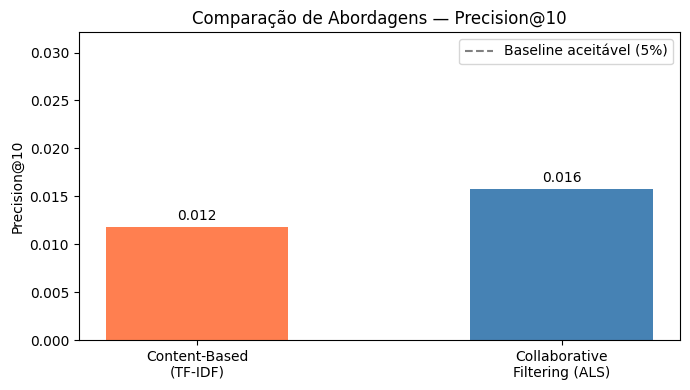

In [19]:
print("Avaliando Content-Based (TF-IDF + Cosine)...")

precisions_cb = []
clientes_avaliacao_cb = np.random.choice(
    list(clientes_com_historico), size=200, replace=False
)

for cid in clientes_avaliacao_cb:
    historico = interactions[interactions['customer_unique_id'] == cid]['product_id'].tolist()
    if len(historico) < 2:
        continue
    produto_ref = historico[0]
    relevantes  = historico[1:]
    recs = recomendar_content_based(produto_ref, n=10)
    if len(recs) == 0:
        continue
    recomendados = recs['product_id'].tolist()
    precisions_cb.append(precision_at_k(recomendados, relevantes, 10))

p_cb = np.mean(precisions_cb) if precisions_cb else 0

resultados = pd.DataFrame({
    'Abordagem': ['Content-Based (TF-IDF)', 'Collaborative Filtering (ALS)'],
    'Precision@10': [f"{p_cb*100:.2f}%", f"{p_cf*100:.2f}%"],
    'Quando usar': [
        'Produto novo ou cliente sem histórico',
        'Cliente com histórico de compras'
    ]
})
display(resultados)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['Content-Based\n(TF-IDF)', 'Collaborative\nFiltering (ALS)'],
               [p_cb, p_cf], color=['coral', 'steelblue'], width=0.5)
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.set_ylabel('Precision@10')
ax.set_title('Comparação de Abordagens — Precision@10')
ax.set_ylim(0, max(p_cb, p_cf) * 1.4 + 0.01)
ax.axhline(0.05, color='gray', linestyle='--', label='Baseline aceitável (5%)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 8. Função Unificada de Recomendação

Função única que decide automaticamente qual abordagem usar com base no perfil do cliente.

In [20]:
def recomendar(customer_unique_id, produto_atual=None, n=10, verbose=True):
    """
    Sistema de recomendação unificado.

    Lógica de decisão:
    1. Cliente com histórico e perfil  → Híbrido (ALS + XGBoost)
    2. Cliente com histórico, sem perfil → CF puro (ALS)
    3. Cliente sem histórico            → Cold Start (estado/categoria)
    4. produto_atual informado          → também retorna "quem comprou também comprou"

    Parâmetros:
    - customer_unique_id : ID do cliente
    - produto_atual      : produto que o cliente está vendo agora (opcional)
    - n                  : número de recomendações
    - verbose            : mostrar qual estratégia foi usada
    """
    tem_historico = customer_unique_id in cliente_idx
    tem_perfil    = customer_unique_id in set(cp['customer_unique_id'])

    if tem_historico and tem_perfil:
        estrategia = "Híbrido (ALS + XGBoost)"
        recomendacoes = recomendar_hibrido(customer_unique_id, n=n)
    elif tem_historico:
        estrategia = "Collaborative Filtering (ALS)"
        recomendacoes = recomendar_cf(customer_unique_id, n=n)
    else:
        estrategia = "Cold Start"
        perfil = customer_prof[customer_prof['customer_unique_id'] == customer_unique_id]
        estado    = perfil['customer_state'].values[0]     if len(perfil) > 0 else None
        categoria = perfil['preferred_category'].values[0] if len(perfil) > 0 else None
        recomendacoes = recomendar_cold_start(estado=estado, categoria=categoria, n=n)

    if verbose:
        print(f"Estratégia usada : {estrategia}")
        print(f"Cliente          : {customer_unique_id[:20]}...")
        print(f"Tem histórico    : {tem_historico} | Tem perfil: {tem_perfil}")
        print()

    resultado = {'estrategia': estrategia, 'recomendacoes': recomendacoes}

    if produto_atual:
        cooc = recomendar_coocorrencia(produto_atual, n=5)
        resultado['tambem_comprou'] = cooc
        if verbose and len(cooc) > 0:
            print("=== Quem comprou o produto atual também comprou: ===")
            display(cooc)

    return resultado


print("=" * 60)
print("DEMO: Cliente com histórico")
print("=" * 60)
res = recomendar(cliente_teste, n=5)
display(res['recomendacoes'])

print()
print("=" * 60)
print("DEMO: Cliente sem histórico (cold start)")
print("=" * 60)
cliente_novo = "id_cliente_que_nao_existe_no_dataset"
res2 = recomendar(cliente_novo, n=5)
display(res2['recomendacoes'])

DEMO: Cliente com histórico
Estratégia usada : Híbrido (ALS + XGBoost)
Cliente          : c8460e4251689ba20504...
Tem histórico    : True | Tem perfil: True



,product_id,categoria,preco_medio,nota_media,score_hibrido
0,52c80cedd4e90108bf4fa6a206ef6b03,garden_tools,173.6912,4.1864,0.993784
1,7fb04722aba7a2b632bac8f9819796f3,health_beauty,82.5874,4.1379,0.992116
2,fb55982be901439613a95940feefd9ee,stationery,80.7857,4.1605,0.990498
3,c4baedd846ed09b85f78a781b522f126,garden_tools,100.5975,4.2013,0.989952
4,42a2c92a0979a949ca4ea89ec5c7b934,housewares,59.3995,4.0000,0.989096



DEMO: Cliente sem histórico (cold start)
Estratégia usada : Cold Start
Cliente          : id_cliente_que_nao_e...
Tem histórico    : False | Tem perfil: False



,rank,product_id,product_category_name_english,avg_review_score,avg_price,total_orders
0,1,aca2eb7d00ea1a7b8ebd4e68314663af,furniture_decor,4.0191,71.3641,527.0
1,2,99a4788cb24856965c36a24e339b6058,bed_bath_table,3.9021,88.1671,488.0
2,3,422879e10f46682990de24d770e7f83d,garden_tools,3.9463,54.9116,484.0
3,4,389d119b48cf3043d311335e499d9c6b,garden_tools,4.1131,54.6954,392.0
4,5,368c6c730842d78016ad823897a372db,garden_tools,3.9227,54.2701,388.0


---
## 9. Salvando os Modelos, Encoders e Artefatos para Produção

Para podermos carregar e utilizar esse sistema de recomendação em qualquer outro lugar (como uma API ou script independente em `src/`), precisamos salvar os modelos treinados, as matrizes e os label encoders/mapeamentos gerados.

In [21]:
import os
import pickle
from scipy.sparse import save_npz

os.makedirs('../models', exist_ok=True)

with open('../models/modelo_als.pkl', 'wb') as f:
    pickle.dump(modelo_als, f)

modelo_xgb.save_model('../models/modelo_xgb.json')

save_npz('../models/matriz_usuario_produto.npz', matriz_usuario_produto)

assets = {
    'cliente_idx': cliente_idx,
    'produto_idx_cf': produto_idx_cf,
    'idx_produto_cf': idx_produto_cf,
    'idx_cliente': idx_cliente,
    'le_state': le_state,
    'le_cat': le_cat,
    'le_pay': le_pay,
    'le_pcat': le_pcat,
    'le_pstate': le_pstate,
    'cp': cp,
    'pf2': pf2,
    'product_feat': product_feat,
    'top_products': top_products,
    'cooccurrence': cooccurrence,
    'FEATURES': FEATURES
}

with open('../models/recomendacao_assets.pkl', 'wb') as f:
    pickle.dump(assets, f)

print("Todos os modelos e artefatos foram salvos com sucesso na pasta '../models/'!")

Todos os modelos e artefatos foram salvos com sucesso na pasta '../models/'!


---
## Resumo do que foi construído

| Módulo | Abordagem | Arquivo Gold usado | Quando é ativado |
|--------|-----------|--------------------|------------------|
| Content-Based | TF-IDF + Cosine Similarity | `gold_product_features` | Página de produto / sem histórico |
| Collaborative Filtering | ALS (implicit) | `gold_user_product_interactions` | Cliente com histórico |
| Cold Start | Top por segmento | `gold_top_products_by_segment` | Cliente novo |
| "Também comprou" | Jaccard (pré-calculado) | `gold_product_cooccurrence` | Produto sendo visualizado |
| Híbrido ranqueador | XGBoost | todos os anteriores | Cliente com histórico + perfil |

### Métricas interpretadas
- **AUC-ROC do XGBoost** → capacidade de distinguir o que o cliente compraria ou não (> 0.7 é bom)
- **Precision@10** → de 10 recomendações, quantas o cliente realmente compraria